In [ ]:
# ============================================================
# HÜCRE 1 — Drive'ı bağla
# ============================================================
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:

# ============================================================
# HÜCRE 2 — Kütüphaneleri yükle (ilk çalıştırmada bir kez)
# ============================================================
!pip install -q diffusers transformers accelerate safetensors


# ============================================================
# HÜCRE 3 — Model + LoRA yükle
# ============================================================
import torch
from diffusers import StableDiffusionPipeline

MODEL_ID  = "runwayml/stable-diffusion-v1-5"
LORA_PATH = "/content/drive/MyDrive/celeba_lora/output_hq_10k_v2/celeba_hq_lora-step00008000.safetensors"


pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")

pipe.load_lora_weights(LORA_PATH)
print("✅ Model + LoRA yüklendi!")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Loading weights:   0%|          | 0/144 [00:00<?, ?it/s]

✅ Model + LoRA yüklendi!


In [ ]:

# ============================================================
# HÜCRE 4 — Descriptions + Negative Prompt
# ============================================================

# ---- BURAYA DESCRIPTION'LARINI YAZ ----
descriptions = [
    "des1: professional portrait photograph, high quality, photorealistic, adult woman, brown eyes, brown hair, fair skin, medium face, medium-width face, oval face, medium chin, medium cheekbones, medium nose, medium-width nose, medium nose bridge, medium nose bridge height, medium nostrils, normal-set eyes, medium eyes, almond-shaped eyes, medium eyebrows, slightly arched eyebrows, full lips, medium-width mouth, medium philtrum, wavy hair, medium hair thickness, rounded hairline, light freckles, tans gradually, medium ears, free earlobes, neutral expression, centered face, soft lighting, plain background",
    "des2: professional portrait photograph, high quality, photorealistic, adult man, brown eyes, brown hair, fair skin, medium face, medium-width face, oval face, medium chin, medium cheekbones, medium nose, medium-width nose, medium nose bridge, medium nose bridge height, medium nostrils, normal-set eyes, medium eyes, almond-shaped eyes, medium eyebrows, slightly arched eyebrows, full lips, medium-width mouth, medium philtrum, wavy hair, medium hair thickness, rounded hairline, light freckles, tans gradually, medium ears, free earlobes, neutral expression, centered face, soft lighting, plain background",
    "des3: professional portrait photograph, high quality, photorealistic, adult woman, bright blue eyes, brown hair, fair skin, medium face, medium-width face, oval face, medium chin, medium cheekbones, medium nose, medium-width nose, medium nose bridge, medium nose bridge height, medium nostrils, normal-set eyes, medium eyes, almond-shaped eyes, medium eyebrows, slightly arched eyebrows, full lips, medium-width mouth, medium philtrum, wavy hair, medium hair thickness, rounded hairline, light freckles, tans gradually, medium ears, free earlobes, neutral expression, centered face, soft lighting, plain background",
    "des4: professional portrait photograph, high quality, photorealistic, adult woman, brown eyes, blonde hair, fair skin, medium face, medium-width face, oval face, medium chin, medium cheekbones, medium nose, medium-width nose, medium nose bridge, medium nose bridge height, medium nostrils, normal-set eyes, medium eyes, almond-shaped eyes, medium eyebrows, slightly arched eyebrows, full lips, medium-width mouth, medium philtrum, wavy hair, medium hair thickness, rounded hairline, light freckles, tans gradually, medium ears, free earlobes, neutral expression, centered face, soft lighting, plain background",
    "des5: professional portrait photograph, high quality, photorealistic, adult woman, brown eyes, brown hair, fair skin, short face, narrow face, oval face, medium chin, medium cheekbones, medium nose, medium-width nose, medium nose bridge, medium nose bridge height, medium nostrils, normal-set eyes, medium eyes, almond-shaped eyes, medium eyebrows, slightly arched eyebrows, full lips, medium-width mouth, medium philtrum, wavy hair, medium hair thickness, rounded hairline, light freckles, tans gradually, medium ears, free earlobes, neutral expression, centered face, soft lighting, plain background",
]

# ---- GENEL NEGATİF PROMPT ----
NEGATIVE_PROMPT = (
    "deformed, ugly, blurry, bad anatomy, bad hands, extra fingers, missing fingers, "
    "fused fingers, too many fingers, mutated hands, poorly drawn hands, poorly drawn face, "
    "mutation, disfigured, extra limbs, cloned face, malformed limbs, missing arms, "
    "missing legs, extra arms, extra legs, low quality, worst quality, jpeg artifacts, "
    "watermark, signature, text, cropped, out of frame, duplicate, morbid, gross proportions, "
    "long neck, asymmetrical eyes, crossed eyes, lazy eye, skin blemishes, acne, "
    "overexposed, underexposed, cartoon, anime, illustration, painting, drawing, sketch, "
    "3d render, cgi, plastic skin, doll-like"
)

# ---- SEED (None = rastgele, int = sabit sonuç) ----
SEED = None   # sabit istersen: SEED = 42


Token indices sequence length is longer than the specified maximum sequence length for this model (133 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['shaped eyes , medium eyebrows , slightly arched eyebrows , full lips , medium - width mouth , medium philtrum , wavy hair , medium hair thickness , rounded hairline , light freckles , tans gradually , medium ears , free earlobes , neutral expression , centered face , soft lighting , plain background']


[1/5] Üretiliyor: des1: professional portrait photograph, high quality, photorealistic, adult woma


  0%|          | 0/30 [00:00<?, ?it/s]

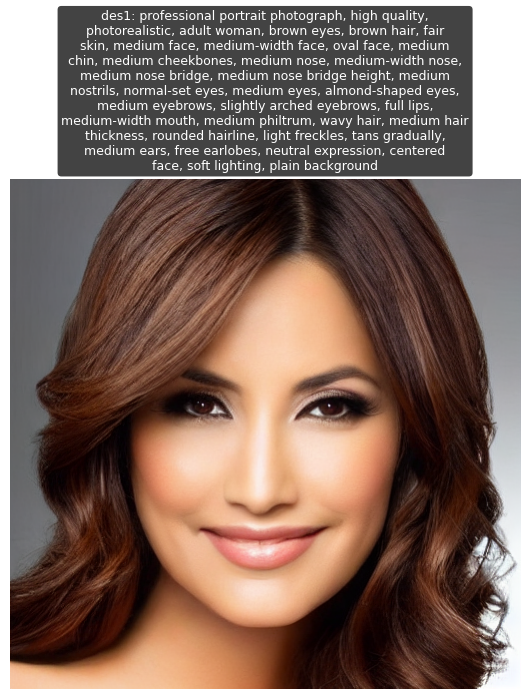

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['shaped eyes , medium eyebrows , slightly arched eyebrows , full lips , medium - width mouth , medium philtrum , wavy hair , medium hair thickness , rounded hairline , light freckles , tans gradually , medium ears , free earlobes , neutral expression , centered face , soft lighting , plain background']


[2/5] Üretiliyor: des2: professional portrait photograph, high quality, photorealistic, adult man,


  0%|          | 0/30 [00:00<?, ?it/s]

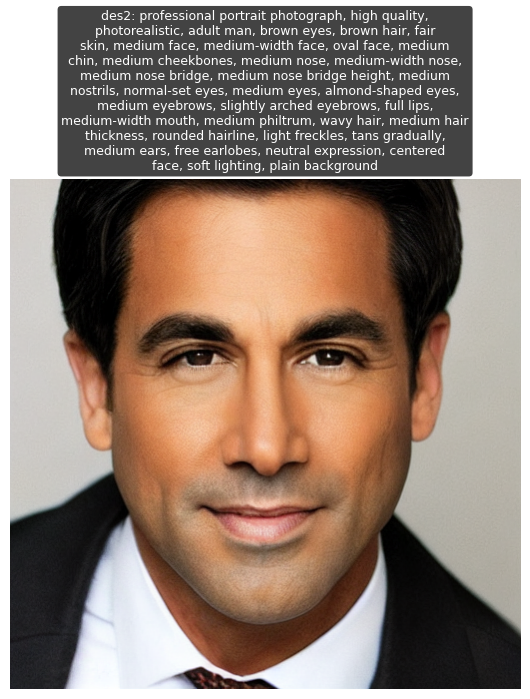

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['- shaped eyes , medium eyebrows , slightly arched eyebrows , full lips , medium - width mouth , medium philtrum , wavy hair , medium hair thickness , rounded hairline , light freckles , tans gradually , medium ears , free earlobes , neutral expression , centered face , soft lighting , plain background']


[3/5] Üretiliyor: des3: professional portrait photograph, high quality, photorealistic, adult woma


  0%|          | 0/30 [00:00<?, ?it/s]

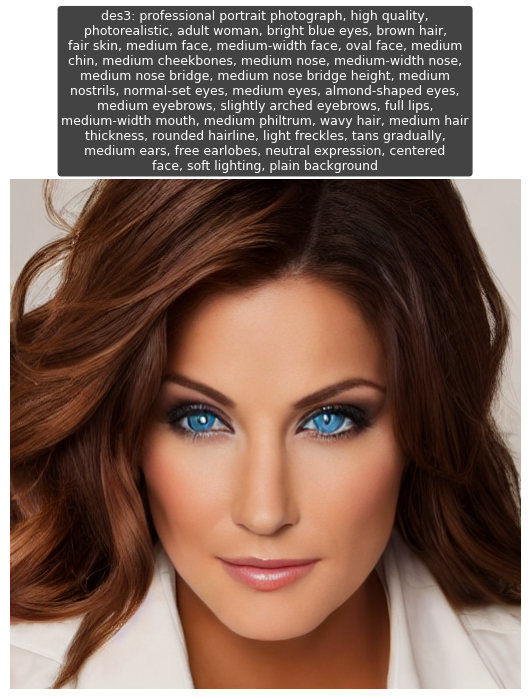

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['shaped eyes , medium eyebrows , slightly arched eyebrows , full lips , medium - width mouth , medium philtrum , wavy hair , medium hair thickness , rounded hairline , light freckles , tans gradually , medium ears , free earlobes , neutral expression , centered face , soft lighting , plain background']


[4/5] Üretiliyor: des4: professional portrait photograph, high quality, photorealistic, adult woma


  0%|          | 0/30 [00:00<?, ?it/s]

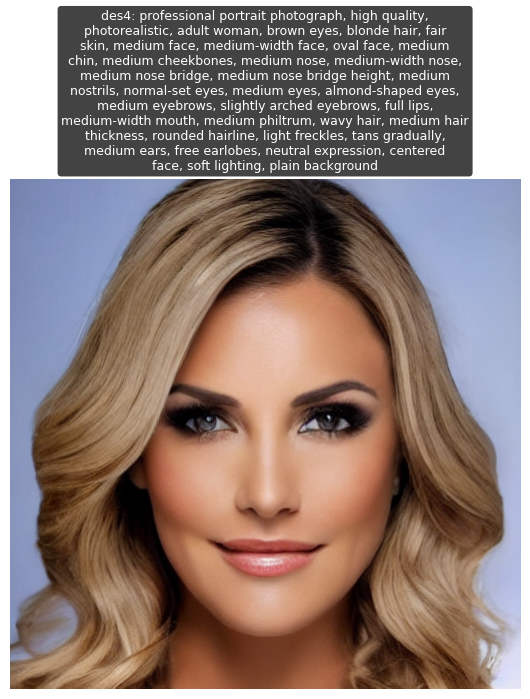

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', medium eyebrows , slightly arched eyebrows , full lips , medium - width mouth , medium philtrum , wavy hair , medium hair thickness , rounded hairline , light freckles , tans gradually , medium ears , free earlobes , neutral expression , centered face , soft lighting , plain background']


[5/5] Üretiliyor: des5: professional portrait photograph, high quality, photorealistic, adult woma


  0%|          | 0/30 [00:00<?, ?it/s]

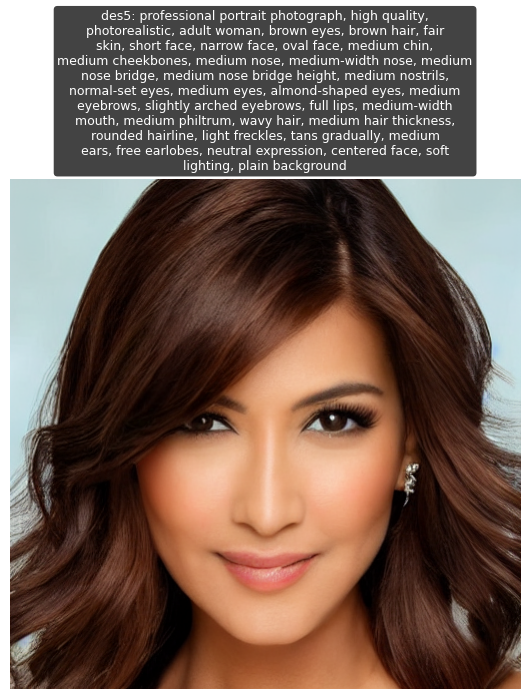

🎉 Bitti!


In [ ]:
# ============================================================
# HÜCRE 5 — Üret ve göster
# ============================================================
import matplotlib.pyplot as plt
import textwrap
from IPython.display import display

for i, desc in enumerate(descriptions):
    label = f"[{i+1}/{len(descriptions)}]"
    print(f"{label} Üretiliyor: {desc[:80]}")

    seed = SEED if SEED is not None else torch.randint(0, 2**32, (1,)).item()
    generator = torch.Generator("cuda").manual_seed(seed)

    image = pipe(
        prompt=desc,
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=30,
        guidance_scale=7.5,
        width=512,
        height=512,
        generator=generator,
    ).images[0]


    # Görselin üstünde description'ı göster
    fig, ax = plt.subplots(figsize=(6, 6.8))
    ax.imshow(image)
    ax.axis("off")

    wrapped = textwrap.fill(desc, width=60)
    ax.set_title(wrapped, fontsize=9, pad=8, wrap=True,
                 bbox=dict(boxstyle="round,pad=0.3", fc="#222222", ec="none", alpha=0.85),
                 color="white")

    plt.tight_layout()
    plt.show()

print("🎉 Bitti!")